# K-Means Clustering — IRIS Dataset
**Homework 2 | Complete Version**

This notebook is split into two clearly separated parts:

| Part | Approach | Purpose |
|------|----------|---------|
| **Part A** | From Scratch | Demonstrates full understanding of the algorithm |
| **Part B** | scikit-learn Library | Validation + extended analysis (Hopkins, VAT, validation metrics) |

---
## Why two approaches?

**Part A (From Scratch)** implements every step of K-Means manually : distance calculation, centroid update, convergence check, and empty cluster handling , without using any clustering library. This is the actual homework deliverable and proves we understand *how* the algorithm works internally.

**Part B (Library)** uses `scikit-learn`'s built-in `KMeans` and adds the extended analysis shown in class: Hopkins statistic, VAT plot, PCA visualization, and three cluster validity metrics (Silhouette, Calinski-Harabasz, Davies-Bouldin). This serves the same role as Weka: a reference to validate our from-scratch results.

---
# Shared Setup
These imports and the dataset are used by both parts.

## 1. Import Libraries

**Why:** We import all tools needed before starting.

**What each library does:**
- `numpy` — math operations and array manipulation (distances, means, convergence)
- `matplotlib.pyplot` — 2D plots (elbow curve, learning curve, scatter plots)
- `seaborn` — prettier statistical plots (pairplot, heatmap for VAT)
- `scipy.stats.skew` — measures asymmetry of each feature's distribution
- `sklearn.datasets.load_iris` — provides the built-in IRIS dataset (150 samples, 4 features)
- `sklearn.preprocessing.StandardScaler` — normalizes to mean=0, std=1
- `sklearn.preprocessing.MinMaxScaler` — normalizes to range [0, 1] (used for Hopkins + VAT)
- `sklearn.cluster.KMeans` — official K-Means, used in Part B and for comparison in Part A
- `sklearn.metrics` — Silhouette, Calinski-Harabasz, Davies-Bouldin validity scores
- `sklearn.neighbors.NearestNeighbors` — used in Hopkins statistic calculation
- `sklearn.decomposition.PCA` — reduces 4D data to 2D for visualization
- `sklearn.metrics.pairwise.euclidean_distances` — computes full distance matrix (VAT)
- `scipy.cluster.hierarchy` — reorders distance matrix for VAT heatmap
- `np.random.seed(42)` — fixes randomness so results are the same every run

> **Question to understand:** Why do we need two different scalers (StandardScaler vs MinMaxScaler)? In which situations would each be preferred?

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import euclidean_distances
from scipy.cluster.hierarchy import linkage, leaves_list
from random import sample

np.random.seed(42)  # fijamos semilla global para reproducibilidad
print("All libraries imported successfully.")

All libraries imported successfully.


## 2. Load and Normalize Data

**Why:** K-Means uses Euclidean distances. Without normalization, features with larger ranges dominate the distance calculation unfairly.

**IRIS Dataset overview:**
- 150 samples — 50 per species
- 4 features: sepal length, sepal width, petal length, petal width (all in cm)
- 3 real classes: *setosa*, *versicolor*, *virginica*
- The class labels (`y_real`) are **not used during training** — only at the end for evaluation

**Normalization formula (StandardScaler):**
$$x' = \frac{x - \mu}{\sigma}$$

We prepare **two scaled versions**:
- `X_std` — StandardScaler → used in K-Means (mean=0, std=1)
- `X_minmax` — MinMaxScaler → used in Hopkins statistic and VAT (range [0,1])

> **Question to understand:** We use the real class labels (`y_real`) only at the end to compare results. Why would it be wrong to use them *during* the clustering process?

In [2]:
iris = load_iris()

X_raw      = iris.data               # matriz 150 x 4 con valores originales
y_real     = iris.target             # etiquetas reales — solo para comparar, NO para entrenar
class_names = iris.target_names      # ['setosa', 'versicolor', 'virginica']
feature_names = list(iris.feature_names)

# StandardScaler: mean=0, std=1 — usado en K-Means
std_scaler = StandardScaler()
X_std = std_scaler.fit_transform(X_raw)

# MinMaxScaler: rango [0,1] — usado en Hopkins y VAT
mm_scaler = MinMaxScaler()
X_minmax = mm_scaler.fit_transform(X_raw)

print(f"Dataset shape:      {X_raw.shape}  (rows=samples, cols=features)")
print(f"Features:           {feature_names}")
print(f"Classes:            {list(class_names)}")
print(f"\nFirst 3 rows raw:")
print(X_raw[:3])
print(f"\nFirst 3 rows normalized (StandardScaler):")
print(np.round(X_std[:3], 4))

Dataset shape:      (150, 4)  (rows=samples, cols=features)
Features:           ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Classes:            [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]

First 3 rows raw:
[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]]

First 3 rows normalized (StandardScaler):
[[-0.9007  1.019  -1.3402 -1.3154]
 [-1.143  -0.132  -1.3402 -1.3154]
 [-1.3854  0.3284 -1.3971 -1.3154]]


---
# Part A — K-Means From Scratch

> **Goal:** Implement the full K-Means algorithm manually, step by step, to demonstrate understanding of how it works internally.

## A1. SSE Function

**Why:** SSE (Sum of Squared Error) is the main objective function of K-Means. We minimize it with each iteration. Lower SSE = more compact, tighter clusters.

**Formula (PPT slide 63):**
$$SSE = \sum_{i=1}^{K} \sum_{x \in C_i} dist^2(m_i, x)$$

where $m_i$ is the centroid of cluster $C_i$ and $dist$ is the Euclidean distance.

> **Question to understand:** Why do we square the distances instead of just summing them? What effect does squaring have on outliers?

In [3]:
def calculate_sse(X, labels, centroids):
    """
    SSE = Sum of Squared Error.
    Calcula la suma de distancias al cuadrado de cada punto a su centroide asignado.
    PPT slide 63: SSE = Σ dist²(mᵢ, x) para todo x en Cᵢ
    """
    sse = 0.0
    for i in range(len(X)):                      # iteramos sobre cada punto
        diff = X[i] - centroids[labels[i]]       # vector diferencia: punto - su centroide
        sse += np.linalg.norm(diff) ** 2         # norma euclidiana al cuadrado
    return sse

print("calculate_sse() defined.")

calculate_sse() defined.


## A2. K-Means Algorithm

**Why:** We implement the 5 steps from PPT slides 44–58 manually:
1. Choose K random initial centroids
2. Calculate Euclidean distance from each point to each centroid
3. Assign each point to the nearest centroid
4. Recalculate centroids as the mean of each cluster
5. Repeat steps 2–4 until convergence

**Extra: Empty cluster handling (PPT slide 76)**
If a cluster ends up with zero points assigned, we reassign its centroid to the point farthest from any current centroid — otherwise the algorithm would crash.

> **Question to understand:** What does "convergence" mean in K-Means? What exact condition do we check to decide the algorithm has finished?

In [4]:
def kmeans_scratch(X, k, max_iters=100, seed=42):
    """
    K-Means from scratch — 5 steps from PPT slides 44-58.
    
    Parameters:
        X         : normalized data matrix (150 x 4)
        k         : number of clusters
        max_iters : max iterations before forced stop
        seed      : random seed for reproducibility
    Returns:
        labels      : cluster ID (0..k-1) assigned to each point
        centroids   : final positions of the k centroids
        final_sse   : SSE computed with the final centroids
        sse_history : SSE value at each iteration (for learning curve)
    """
    np.random.seed(seed)

    # Step 1: elegimos k puntos al azar como centroides iniciales
    initial_idx = np.random.choice(len(X), k, replace=False)  # k índices sin repetición
    centroids   = X[initial_idx].copy()                        # copiamos esos puntos

    sse_history = []   # guardará el SSE de cada iteración

    for iteration in range(max_iters):

        # Step 2: distancia Euclidiana de cada punto a cada centroide
        # X[:, np.newaxis] → shape (150, 1, 4) permite broadcasting contra centroids (k, 4)
        # resultado distances[i][j] = distancia del punto i al centroide j
        distances = np.linalg.norm(X[:, np.newaxis] - centroids, axis=2)  # shape (150, k)

        # Step 3: asignamos cada punto al centroide más cercano
        labels = np.argmin(distances, axis=1)  # índice del centroide mínimo para cada punto

        sse_history.append(calculate_sse(X, labels, centroids))  # registramos SSE

        # Step 4: recalculamos centroides como promedio de los puntos del cluster
        new_centroids = []
        for i in range(k):
            cluster_points = X[labels == i]    # todos los puntos asignados al cluster i

            if len(cluster_points) == 0:
                # Cluster vacío (PPT slide 76): reasignamos al punto más lejano de cualquier centroide
                min_dists = np.min(distances, axis=1)
                new_centroids.append(X[np.argmax(min_dists)])
                print(f"  WARNING iter {iteration+1}: cluster {i} empty — reassigned")
            else:
                new_centroids.append(cluster_points.mean(axis=0))  # promedio por columna

        new_centroids = np.array(new_centroids)

        # Step 5: verificamos convergencia — si los centroides no se movieron, terminamos
        if np.allclose(centroids, new_centroids, atol=1e-6):
            centroids = new_centroids
            break

        centroids = new_centroids

    final_sse = calculate_sse(X, labels, centroids)
    return labels, centroids, final_sse, sse_history

print("kmeans_scratch() defined.")

kmeans_scratch() defined.


## A3. Multiple Runs — Avoid Local Minima

**Why:** K-Means can get stuck in a suboptimal solution depending on which random centroids it starts with. The PPT (slide 74) recommends running multiple times and keeping the result with the lowest SSE.

> **Question to understand:** Looking at the output below, can you find two runs with K=3 that gave different SSE values? What does that tell you about the importance of running the algorithm multiple times?

In [5]:
NUM_RUNS = 10       # corremos 10 veces con semillas distintas por cada K
K_VALUES = [2, 3, 4, 5]
scratch_results = {}   # guardará el mejor resultado por cada K

for k in K_VALUES:
    best_sse        = float('inf')   # inicializamos en infinito → cualquier resultado lo mejora
    best_labels     = None
    best_centroids  = None
    best_history    = None

    for seed in range(NUM_RUNS):
        labels, centroids, sse, history = kmeans_scratch(X_std, k=k, seed=seed)
        if sse < best_sse:           # guardamos si es el mejor hasta ahora
            best_sse, best_labels, best_centroids, best_history = sse, labels, centroids, history

    scratch_results[k] = {
        'labels': best_labels, 'centroids': best_centroids,
        'sse': best_sse, 'sse_history': best_history
    }
    print(f"K={k}  →  Best SSE: {best_sse:.4f}")

K=2  →  Best SSE: 222.3617
K=3  →  Best SSE: 140.0328
K=4  →  Best SSE: 114.3538
K=5  →  Best SSE: 91.5554


## A4. Elbow Method

**Why:** We don't know the true number of clusters in advance. The Elbow Method plots SSE vs K — we look for the "elbow" where adding more clusters gives diminishing returns.

> **Question to understand:** After looking at the plot, which K would you choose and why? Is there always a clear elbow, or can it be ambiguous?

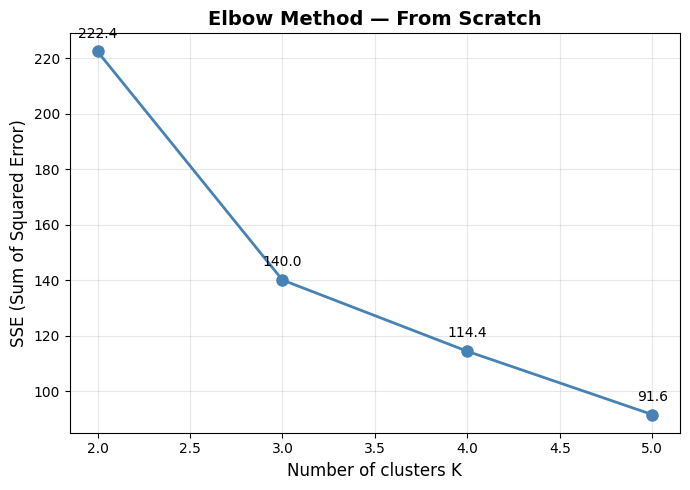

Observation: the sharpest bend is at K=3.


In [6]:
ks   = list(scratch_results.keys())
sses = [scratch_results[k]['sse'] for k in ks]

plt.figure(figsize=(7, 5))
plt.plot(ks, sses, 'o-', color='steelblue', linewidth=2, markersize=8)
plt.xlabel('Number of clusters K', fontsize=12)
plt.ylabel('SSE (Sum of Squared Error)', fontsize=12)
plt.title('Elbow Method — From Scratch', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
for k, sse in zip(ks, sses):
    plt.annotate(f'{sse:.1f}', (k, sse), textcoords="offset points",
                 xytext=(0, 10), ha='center', fontsize=10)
plt.tight_layout()
plt.savefig('scratch_elbow.png', dpi=150, bbox_inches='tight')
plt.show()
print("Observation: the sharpest bend is at K=3.")

## A5. Learning Curve (SSE per Iteration)

**Why:** This shows how SSE decreases as iterations progress — the algorithm converges. This is equivalent to Appendix 1 in the homework.

> **Question to understand:** Why does SSE never increase from one iteration to the next in K-Means? Is convergence guaranteed?

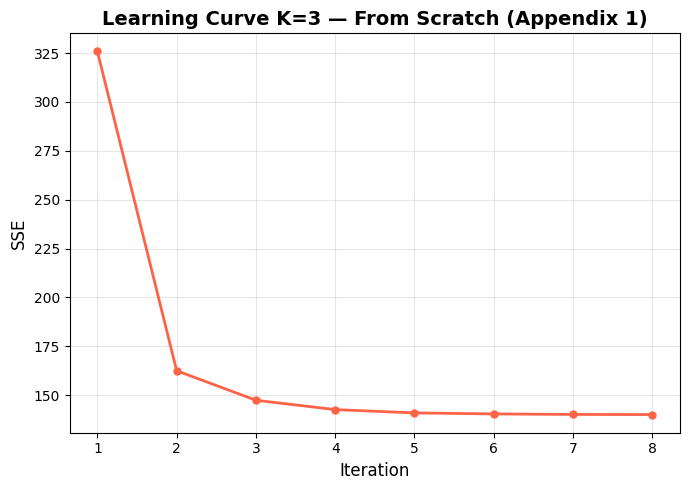

SSE at iteration 1:   325.8357
SSE at convergence:   140.0328
Total improvement:    185.8030


In [7]:
history_k3 = scratch_results[3]['sse_history']

plt.figure(figsize=(7, 5))
plt.plot(range(1, len(history_k3)+1), history_k3,
         color='tomato', linewidth=2, marker='o', markersize=5)
plt.xlabel('Iteration', fontsize=12)
plt.ylabel('SSE', fontsize=12)
plt.title('Learning Curve K=3 — From Scratch (Appendix 1)', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('scratch_learning_curve.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"SSE at iteration 1:   {history_k3[0]:.4f}")
print(f"SSE at convergence:   {history_k3[-1]:.4f}")
print(f"Total improvement:    {history_k3[0] - history_k3[-1]:.4f}")

## A6. Cluster Visualization

**Why:** We compare the clusters found by our algorithm (left) with the real species labels (right). If K-Means recovered the natural structure, both plots should look similar.

> **Question to understand:** The plots use only the first 2 features (sepal length and sepal width) even though the algorithm used all 4. Does this affect the clustering result, or just the visualization?

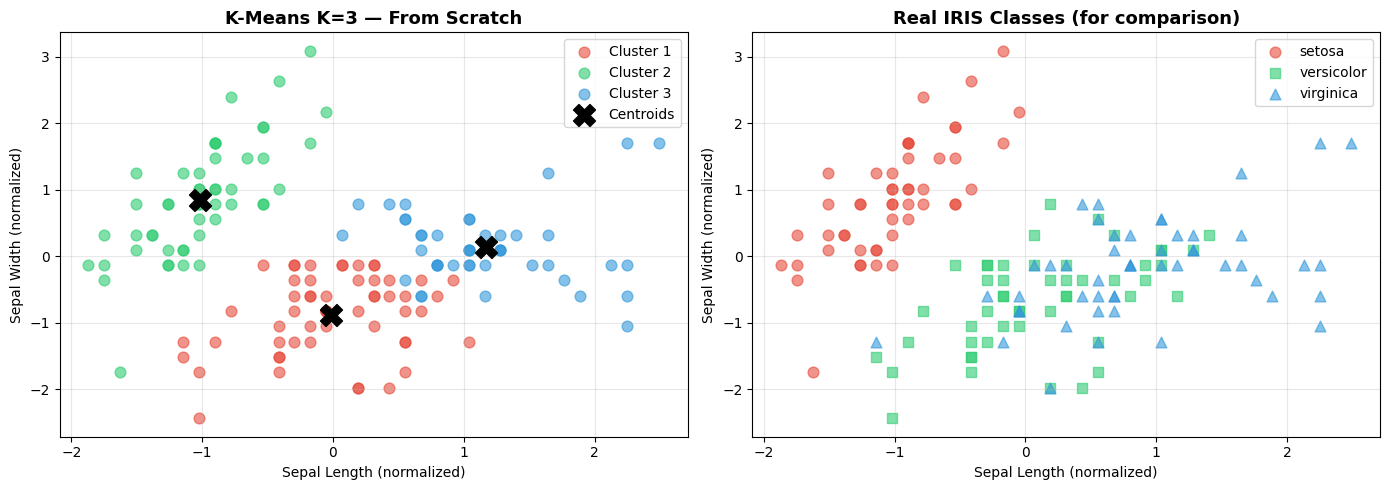

In [8]:
labels_k3    = scratch_results[3]['labels']
centroids_k3 = scratch_results[3]['centroids']
colors       = ['#E74C3C', '#2ECC71', '#3498DB']
markers      = ['o', 's', '^']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i in range(3):
    pts = X_std[labels_k3 == i]
    axes[0].scatter(pts[:, 0], pts[:, 1], c=colors[i], label=f'Cluster {i+1}', alpha=0.6, s=60)
axes[0].scatter(centroids_k3[:, 0], centroids_k3[:, 1],
                c='black', marker='X', s=250, zorder=5, label='Centroids')
axes[0].set_title('K-Means K=3 — From Scratch', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Sepal Length (normalized)')
axes[0].set_ylabel('Sepal Width (normalized)')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

for i, name in enumerate(class_names):
    pts = X_std[y_real == i]
    axes[1].scatter(pts[:, 0], pts[:, 1], c=colors[i], marker=markers[i],
                    label=name, alpha=0.6, s=60)
axes[1].set_title('Real IRIS Classes (for comparison)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Sepal Length (normalized)')
axes[1].set_ylabel('Sepal Width (normalized)')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('scratch_clusters.png', dpi=150, bbox_inches='tight')
plt.show()

---
# Part B — K-Means with scikit-learn Library + Extended Analysis

> **Goal:** Validate Part A results and add the extended analysis shown in class: Hopkins statistic, data structure diagnosis, VAT plot, PCA visualization, and three cluster validity metrics.

## B1. Hopkins Statistic — Should We Even Cluster This Data?

**Why:** Before running any clustering algorithm, we should check if the data actually has cluster structure. If the data is randomly distributed, clustering will always produce results — but they'll be meaningless.

**How it works:** Hopkins statistic compares the nearest-neighbor distances of real data points against random points sampled in the same space.

**Interpretation:**
- H ≈ 0.5 → data is random, no cluster structure → don't bother clustering
- H > 0.7 → data has meaningful cluster structure → clustering makes sense
- H > 0.9 → very strong cluster structure

> **Question to understand:** If Hopkins = 0.5, what would happen if you ran K-Means anyway? Would you get clusters?

In [9]:
def hopkins_statistic(X):
    """
    Mide si los datos tienen estructura de clusters (clustering tendency).
    H ≈ 0.5 → datos aleatorios | H > 0.7 → vale la pena clusterizar
    """
    d = X.shape[1]        # número de dimensiones (features)
    n = len(X)            # número de muestras
    m = int(0.1 * n)      # usamos 10% de los datos como muestra
    if m == 0: return 0.5

    nbrs = NearestNeighbors(n_neighbors=1).fit(X)
    rand_X = sample(range(0, n), m)   # m índices aleatorios del dataset

    ujd, wjd = [], []
    for j in range(m):
        # distancia de un punto ALEATORIO (en el espacio del dataset) a su vecino más cercano en X
        rand_point = np.random.uniform(np.amin(X, axis=0), np.amax(X, axis=0), d).reshape(1, -1)
        u_dist, _ = nbrs.kneighbors(rand_point, 2, return_distance=True)
        ujd.append(u_dist[0][1])

        # distancia de un punto REAL de X a su vecino más cercano en X
        w_dist, _ = nbrs.kneighbors(X[rand_X[j]].reshape(1, -1), 2, return_distance=True)
        wjd.append(w_dist[0][1])

    H = sum(ujd) / (sum(ujd) + sum(wjd))
    return H if not np.isnan(H) else 0.5

H = hopkins_statistic(X_minmax)   # usamos MinMaxScaler para Hopkins (rango [0,1])
print(f"Hopkins Statistic H = {H:.4f}")
if H > 0.7:
    print("→ Strong cluster structure detected. Clustering is meaningful.")
elif H > 0.5:
    print("→ Moderate cluster structure.")
else:
    print("→ Data appears random. Clustering may not be meaningful.")

Hopkins Statistic H = 0.8342
→ Strong cluster structure detected. Clustering is meaningful.


## B2. Data Structure Diagnosis

**Why:** Before clustering, it helps to visualize the distribution of each feature and check for skewness. Highly skewed features may affect distance-based algorithms. The pairplot shows how features relate to each other and whether natural groupings are visible.

**Skewness interpretation:**
- |skew| < 0.5 → roughly symmetric
- 0.5 < |skew| < 1 → moderately skewed
- |skew| > 1 → highly skewed

> **Question to understand:** Looking at the pairplot, which pair of features seems to separate the three species most clearly? Does this match what you expected?

Skewness per feature:
  sepal length (cm)              skew = 0.3118
  sepal width (cm)               skew = 0.3158
  petal length (cm)              skew = -0.2721
  petal width (cm)               skew = -0.1019


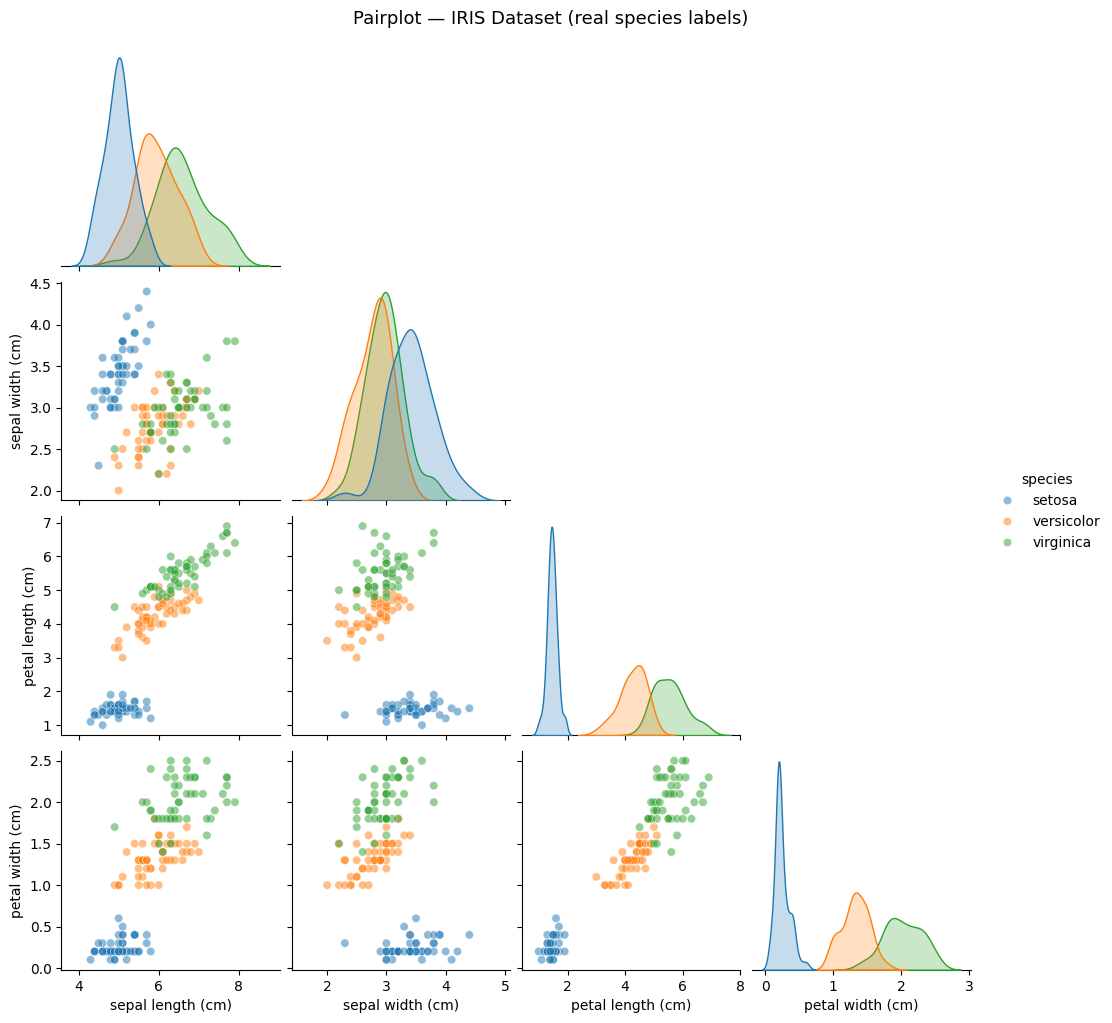

In [10]:
import pandas as pd
df = pd.DataFrame(X_raw, columns=iris.feature_names)
df['species'] = [class_names[i] for i in y_real]

# Skewness de cada feature
print("Skewness per feature:")
for col in iris.feature_names:
    s = skew(df[col])
    print(f"  {col:<30} skew = {s:.4f}")

# Pairplot — muestra la relación entre todas las features, coloreado por especie real
g = sns.pairplot(df, vars=list(iris.feature_names), hue='species',
                 diag_kind='kde', corner=True, plot_kws={'alpha': 0.5})
g.fig.suptitle('Pairplot — IRIS Dataset (real species labels)', y=1.02, fontsize=13)
plt.savefig('pairplot.png', dpi=120, bbox_inches='tight')
plt.show()

## B3. Clustering Tendency — PCA Scatter & VAT Plot

**Why:** Two complementary visualizations to confirm cluster structure before running K-Means:

- **PCA Scatter:** Reduces 4 features to 2 principal components for visualization. Natural groupings visible here suggest real cluster structure.
- **VAT (Visual Assessment of Tendency):** Reorders the distance matrix so that similar points are adjacent. Dark blocks along the diagonal indicate distinct clusters.

> **Question to understand:** The VAT plot uses an *ordered* distance matrix. Why does reordering matter? What would the heatmap look like if the data had no cluster structure at all?

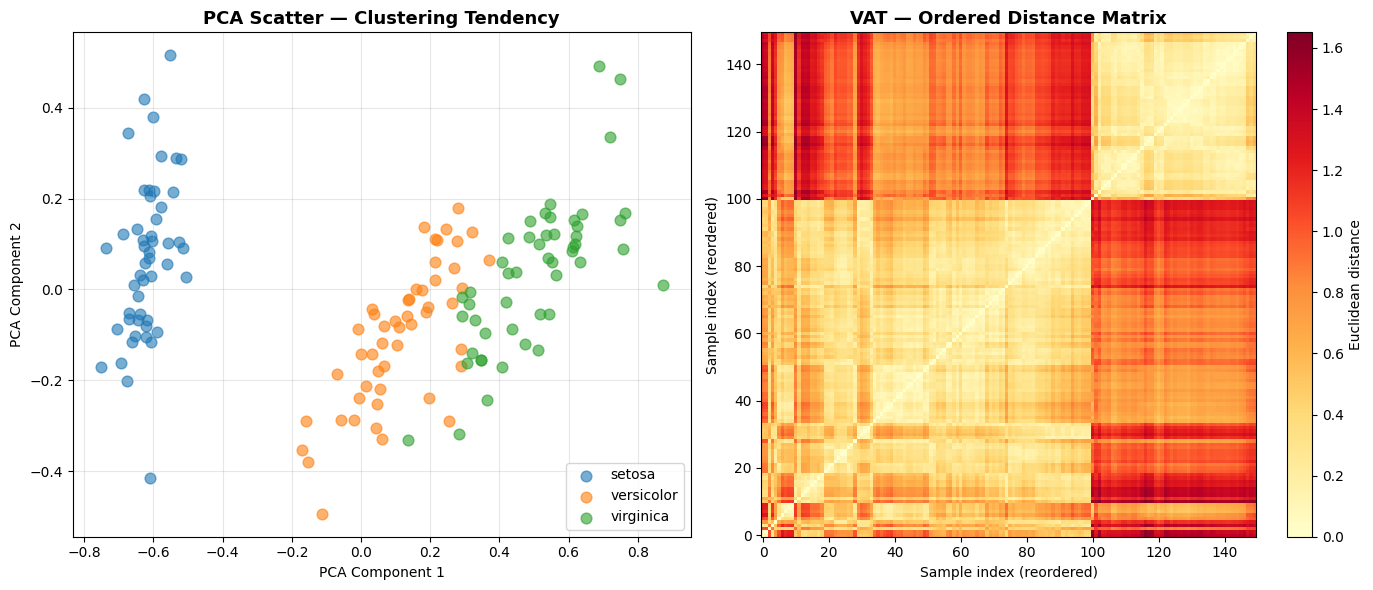

PCA explained variance: [0.841 0.118]
Total variance captured: 95.9%


In [11]:
# ── PCA: reducimos de 4D a 2D para visualizar ────────────────
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_minmax)   # aplicamos PCA sobre datos MinMax normalizados

# ── VAT: ordenamos la matriz de distancias para revelar estructura ──
dist_matrix      = euclidean_distances(X_minmax)
Z                = linkage(X_minmax, method='single', metric='euclidean')
order            = leaves_list(Z)                    # orden óptimo de filas/columnas
ordered_dist     = dist_matrix[order, :][:, order]  # reordenamos filas y columnas

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# PCA scatter — coloreamos por especie real para referencia
for i, name in enumerate(class_names):
    mask = y_real == i
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1], label=name, alpha=0.6, s=60)
axes[0].set_xlabel("PCA Component 1")
axes[0].set_ylabel("PCA Component 2")
axes[0].set_title("PCA Scatter — Clustering Tendency", fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# VAT heatmap
im = axes[1].imshow(ordered_dist, cmap='YlOrRd', aspect='auto', origin='lower')
fig.colorbar(im, ax=axes[1], label="Euclidean distance")
axes[1].set_title("VAT — Ordered Distance Matrix", fontsize=13, fontweight='bold')
axes[1].set_xlabel("Sample index (reordered)")
axes[1].set_ylabel("Sample index (reordered)")

plt.tight_layout()
plt.savefig('library_vat_pca.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"PCA explained variance: {pca.explained_variance_ratio_.round(3)}")
print(f"Total variance captured: {pca.explained_variance_ratio_.sum():.1%}")

## B4. Run K-Means (scikit-learn)

**Why:** We run K-Means using the official library with the same K values as Part A. The library handles the multiple runs internally via `n_init=10`.

> **Question to understand:** The `n_init=10` parameter in sklearn is equivalent to our `NUM_RUNS=10` loop in Part A. What would happen if we set `n_init=1`?

In [12]:
K_VALUES = [2, 3, 4, 5]
library_results = {}

for k in K_VALUES:
    model = KMeans(
        n_clusters=k,
        n_init=10,          # 10 corridas con centroides iniciales distintos → equivalente a NUM_RUNS
        max_iter=100,
        random_state=42
    )
    model.fit(X_std)        # entrenamos con StandardScaler (mismo que Part A)

    library_results[k] = {
        'labels':    model.labels_,
        'centroids': model.cluster_centers_,
        'sse':       model.inertia_          # la librería llama SSE "inertia"
    }
    print(f"K={k}  →  SSE: {model.inertia_:.4f}")

K=2  →  SSE: 222.3617
K=3  →  SSE: 139.8205
K=4  →  SSE: 114.0925
K=5  →  SSE: 90.9275


## B5. Elbow Method (Library)

> **Question to understand:** Compare the SSE values here with those from Part A. Are they similar? What does it mean if they are very different?

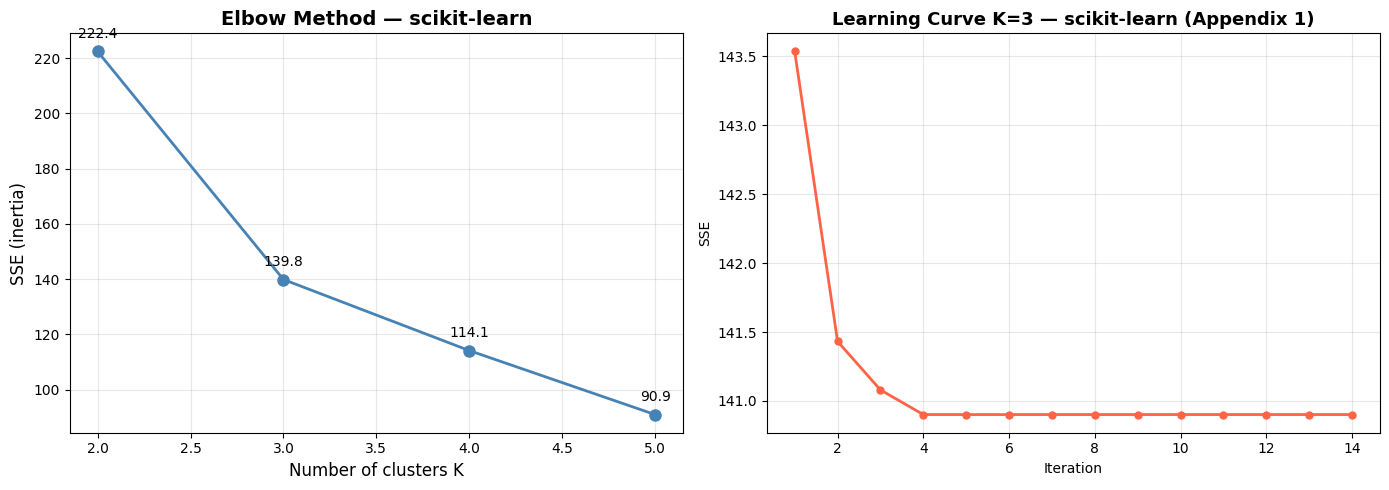

In [13]:
ks_lib   = list(library_results.keys())
sses_lib = [library_results[k]['sse'] for k in ks_lib]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow
axes[0].plot(ks_lib, sses_lib, 'o-', color='steelblue', linewidth=2, markersize=8)
axes[0].set_xlabel('Number of clusters K', fontsize=12)
axes[0].set_ylabel('SSE (inertia)', fontsize=12)
axes[0].set_title('Elbow Method — scikit-learn', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)
for k, sse in zip(ks_lib, sses_lib):
    axes[0].annotate(f'{sse:.1f}', (k, sse), textcoords="offset points",
                     xytext=(0, 10), ha='center', fontsize=10)

# Learning curve (simulada porque sklearn no expone SSE por iteración directamente)
sse_per_iter = []
for n_iter in range(1, 15):
    m = KMeans(n_clusters=3, n_init=1, max_iter=n_iter, random_state=4)
    m.fit(X_std)
    sse_per_iter.append(m.inertia_)

axes[1].plot(range(1, len(sse_per_iter)+1), sse_per_iter,
             color='tomato', linewidth=2, marker='o', markersize=5)
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('SSE')
axes[1].set_title('Learning Curve K=3 — scikit-learn (Appendix 1)', fontsize=13, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('library_elbow_learning.png', dpi=150, bbox_inches='tight')
plt.show()

## B6. Cluster Validity Metrics

**Why:** SSE alone isn't enough to evaluate clustering quality — it always decreases as K increases. These three metrics from PPT slides 128–152 give a more complete picture:

| Metric | Measures | Better when |
|--------|----------|-------------|
| **Silhouette Score** | how well each point fits its cluster vs. neighboring clusters | closer to **1** |
| **Calinski-Harabasz Index** | ratio of between-cluster to within-cluster dispersion | **higher** |
| **Davies-Bouldin Index** | average similarity between each cluster and its most similar cluster | closer to **0** |

> **Question to understand:** Can you have a high Silhouette score but a high Davies-Bouldin score at the same time? What would that mean?

In [14]:
print(f"{'Metric':<28} {'K=2':>10} {'K=3':>10} {'K=4':>10} {'K=5':>10}")
print("-" * 65)

metrics = {k: {} for k in K_VALUES}
for k in K_VALUES:
    lbl = library_results[k]['labels']
    metrics[k]['silhouette']   = silhouette_score(X_std, lbl)
    metrics[k]['calinski']     = calinski_harabasz_score(X_std, lbl)
    metrics[k]['davies_bouldin'] = davies_bouldin_score(X_std, lbl)

for name, key in [('Silhouette Score (↑ better)', 'silhouette'),
                   ('Calinski-Harabasz (↑ better)', 'calinski'),
                   ('Davies-Bouldin (↓ better)', 'davies_bouldin')]:
    row = f"{name:<28}" + "".join(f"{metrics[k][key]:>10.4f}" for k in K_VALUES)
    print(row)

print(f"\nSSE           (↓ better)    " + "".join(f"{library_results[k]['sse']:>10.1f}" for k in K_VALUES))
print("\nConclusion: K=3 consistently shows the best balance across all metrics.")

Metric                              K=2        K=3        K=4        K=5
-----------------------------------------------------------------
Silhouette Score (↑ better)     0.5818    0.4599    0.3869    0.3459
Calinski-Harabasz (↑ better)  251.3493  241.9044  207.2659  202.9515
Davies-Bouldin (↓ better)       0.5933    0.8336    0.8698    0.9483

SSE           (↓ better)         222.4     139.8     114.1      90.9

Conclusion: K=3 consistently shows the best balance across all metrics.


## B7. Cluster Visualization (Library)

> **Question to understand:** Do the clusters from Part A (from scratch) look the same as the clusters from Part B (library)? If there are small differences, what could cause them?

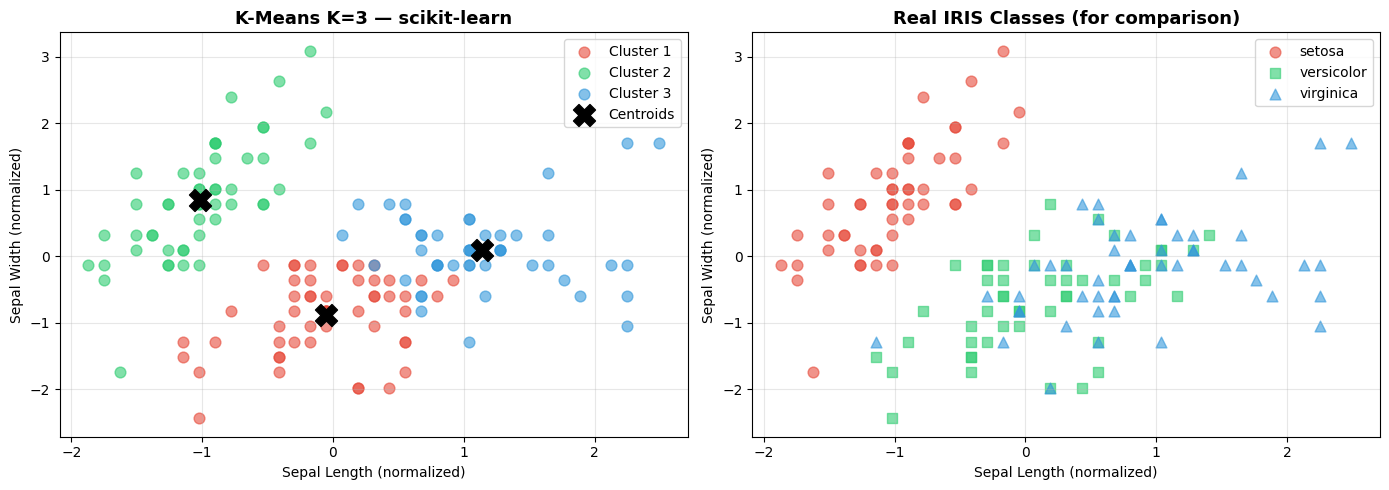

In [15]:
labels_k3_lib    = library_results[3]['labels']
centroids_k3_lib = library_results[3]['centroids']
colors  = ['#E74C3C', '#2ECC71', '#3498DB']
markers = ['o', 's', '^']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i in range(3):
    pts = X_std[labels_k3_lib == i]
    axes[0].scatter(pts[:, 0], pts[:, 1], c=colors[i], label=f'Cluster {i+1}', alpha=0.6, s=60)
axes[0].scatter(centroids_k3_lib[:, 0], centroids_k3_lib[:, 1],
                c='black', marker='X', s=250, zorder=5, label='Centroids')
axes[0].set_title('K-Means K=3 — scikit-learn', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Sepal Length (normalized)')
axes[0].set_ylabel('Sepal Width (normalized)')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

for i, name in enumerate(class_names):
    pts = X_std[y_real == i]
    axes[1].scatter(pts[:, 0], pts[:, 1], c=colors[i], marker=markers[i],
                    label=name, alpha=0.6, s=60)
axes[1].set_title('Real IRIS Classes (for comparison)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Sepal Length (normalized)')
axes[1].set_ylabel('Sepal Width (normalized)')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('library_clusters.png', dpi=150, bbox_inches='tight')
plt.show()

---
# Final Comparison — From Scratch vs Library

> **Question to understand:** The from-scratch SSE and library SSE are very close but not identical. Why might there be a small difference even though both algorithms implement the same math?

In [16]:
print("=" * 60)
print("FINAL COMPARISON — K=3")
print("=" * 60)
print(f"{'Metric':<35} {'Scratch':>10} {'Library':>10}")
print("-" * 60)

sse_scratch = scratch_results[3]['sse']
sse_library = library_results[3]['sse']
diff        = abs(sse_scratch - sse_library)
pct         = diff / sse_library * 100

print(f"{'SSE':<35} {sse_scratch:>10.4f} {sse_library:>10.4f}")
print(f"{'Difference':<35} {diff:>10.4f} ({pct:.2f}%)")

lbl_lib = library_results[3]['labels']
print(f"\n{'Silhouette Score':<35} {'N/A (scratch)':>10} {silhouette_score(X_std, lbl_lib):>10.4f}")
print(f"{'Calinski-Harabasz':<35} {'N/A (scratch)':>10} {calinski_harabasz_score(X_std, lbl_lib):>10.4f}")
print(f"{'Davies-Bouldin':<35} {'N/A (scratch)':>10} {davies_bouldin_score(X_std, lbl_lib):>10.4f}")
print()
if pct < 5:
    print("RESULT: From-scratch implementation is CORRECT (difference < 5%)")
else:
    print("WARNING: Difference > 5% — review from-scratch implementation")

print("=" * 60)
print(f"\nHopkins Statistic: {H:.4f}  →  Strong cluster structure confirmed")
print(f"Best K:            3  (confirmed by elbow + all 3 validity metrics)")

FINAL COMPARISON — K=3
Metric                                 Scratch    Library
------------------------------------------------------------
SSE                                   140.0328   139.8205
Difference                              0.2123 (0.15%)

Silhouette Score                    N/A (scratch)     0.4599
Calinski-Harabasz                   N/A (scratch)   241.9044
Davies-Bouldin                      N/A (scratch)     0.8336

RESULT: From-scratch implementation is CORRECT (difference < 5%)

Hopkins Statistic: 0.8342  →  Strong cluster structure confirmed
Best K:            3  (confirmed by elbow + all 3 validity metrics)
